In [1]:
def start_signature():
    print("="*40)
    print("START OF NOTEBOOK — AT")
    print("="*40)

start_signature()

from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1) CONNECT TO POSTGRES
# ----------------------------
PG_USER = "postgres"
PG_PASSWORD = "postgre_mimic"
PG_HOST = "127.0.0.1"
PG_PORT = "5433"
PG_DB = "mimic_raw"

engine = create_engine(
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

pd.read_sql("SELECT current_database(), current_user;", engine)
pd.read_sql("SELECT version();", engine)
pd.read_sql("SELECT COUNT(*) FROM raw.transfers;", engine)

print("✅ Connected to PostgreSQL")

START OF NOTEBOOK — AT
✅ Connected to PostgreSQL


In [2]:
# ----------------------------
# 2) PULL MODEL BASE (Neurology + age>=65)
# ----------------------------
units = ["Neurology"]

df_merge2 = pd.read_sql(
    """
    SELECT *
    FROM dm.model_base_by_unit
    WHERE careunit = 'Neurology'
      AND anchor_age >= 65
      AND unit_los_hours IS NOT NULL
      AND unit_los_hours > 0
    """,
    engine
)

print("Rows pulled (Neurology, 65+):", df_merge2.shape)
print(df_merge2.head())
df_merge2.info()

# Rename target
df_merge2 = df_merge2.rename(columns={"unit_los_hours": "LOS_Neurology_hours"}).copy()

Rows pulled (Neurology, 65+): (14557, 34)
    hadm_id  subject_id   careunit         unit_intime        unit_outtime  \
0  22672901    10001667  Neurology 2173-08-23 19:51:20 2173-08-24 17:28:00   
1  25679292    10001877  Neurology 2149-05-21 17:15:00 2149-05-27 13:40:43   
2  28439444    10002155  Neurology 2128-07-29 17:02:14 2128-07-31 18:10:19   
3  28676446    10002428  Neurology 2157-07-16 06:03:28 2157-07-18 16:50:05   
4  22014575    10012476  Neurology 2163-01-11 15:16:30 2163-01-23 14:46:43   

   unit_los_hours gender  anchor_age           admittime     admission_type  \
0           21.61      F          86 2173-08-22 17:16:00  OBSERVATION ADMIT   
1          140.43      M          89 2149-05-21 15:53:00           EW EMER.   
2           49.13      F          80 2128-07-29 17:01:00           EW EMER.   
3           55.76      F          80 2157-07-16 04:09:00     EU OBSERVATION   
4          287.50      M          88 2163-01-09 22:40:00           EW EMER.   

   ... nervous

In [3]:
# ----------------------------
# 3) TIMING FEATURES
# ----------------------------
df_merge2["admittime"]   = pd.to_datetime(df_merge2["admittime"], errors="coerce")
df_merge2["unit_intime"] = pd.to_datetime(df_merge2["unit_intime"], errors="coerce")
df_merge2["unit_outtime"] = pd.to_datetime(df_merge2["unit_outtime"], errors="coerce")

df_merge2 = df_merge2.dropna(subset=["admittime", "unit_intime"]).copy()

df_merge2["hours_to_neurology"] = (
    (df_merge2["unit_intime"] - df_merge2["admittime"]).dt.total_seconds() / 3600.0
)
df_merge2["hours_to_neurology"] = df_merge2["hours_to_neurology"].clip(lower=0)

df_merge2["neurology_entry_hour"]  = df_merge2["unit_intime"].dt.hour
df_merge2["neurology_entry_day"]   = df_merge2["unit_intime"].dt.dayofweek
df_merge2["neurology_entry_month"] = df_merge2["unit_intime"].dt.month

df_merge2["admit_hour"]  = df_merge2["admittime"].dt.hour
df_merge2["admit_day"]   = df_merge2["admittime"].dt.dayofweek
df_merge2["admit_month"] = df_merge2["admittime"].dt.month

print("✅ Timing features created. Shape:", df_merge2.shape)

✅ Timing features created. Shape: (14557, 41)


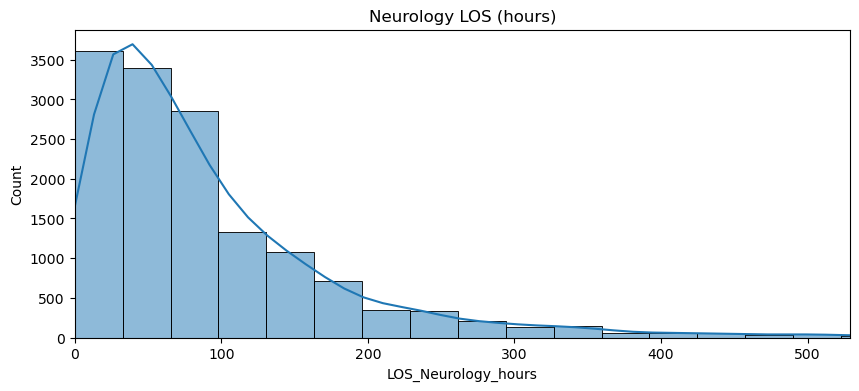

In [4]:
# ----------------------------
# 4) OPTIONAL QUICK CHECK
# ----------------------------
plt.figure(figsize=(10, 4))
sns.histplot(df_merge2["LOS_Neurology_hours"], bins=80, kde=True)
plt.title("Neurology LOS (hours)")
plt.xlim(0, df_merge2["LOS_Neurology_hours"].quantile(0.99))
plt.show()

In [5]:
# ----------------------------
# 5) LAB FEATURES
# ----------------------------
df_labitems = pd.read_sql("""SELECT itemid, label FROM dm.dim_labitems;""", engine)

NEURO_LABS = {
    "Sodium", "Potassium", "Chloride", "Bicarbonate",
    "Creatinine", "Urea Nitrogen", "Glucose",
    "White Blood Cells", "Hemoglobin", "Platelet Count",
    "INR(PT)", "PT", "PTT"
}

neuro_labitems = df_labitems[df_labitems["label"].isin(NEURO_LABS)].copy()
neuro_lab_itemids = set(neuro_labitems["itemid"].unique())

print("Selected Neuro lab labels found:")
print(neuro_labitems["label"].value_counts())
print("ItemIDs to keep:", neuro_lab_itemids)

Selected Neuro lab labels found:
label
Glucose              5
Hemoglobin           3
Potassium            3
White Blood Cells    3
Chloride             2
INR(PT)              2
Creatinine           2
Urea Nitrogen        2
Sodium               2
PT                   2
Platelet Count       2
PTT                  2
Bicarbonate          1
Name: count, dtype: int64
ItemIDs to keep: {np.int64(52610), np.int64(51981), np.int64(52623), np.int64(50833), np.int64(51222), np.int64(51478), np.int64(50971), np.int64(51237), np.int64(50983), np.int64(52647), np.int64(51755), np.int64(51756), np.int64(52535), np.int64(51640), np.int64(52921), np.int64(52923), np.int64(51006), np.int64(51265), np.int64(50882), np.int64(52546), np.int64(53189), np.int64(51274), np.int64(51275), np.int64(50902), np.int64(52569), np.int64(51675), np.int64(50912), np.int64(51301), np.int64(50931), np.int64(50809), np.int64(50811)}


In [6]:
neuro_hadm_ids = set(df_merge2["hadm_id"].dropna().unique())
print("Neurology admissions used for labs:", len(neuro_hadm_ids))

neuro_entry_map = (
    df_merge2[["hadm_id", "unit_intime"]]
    .dropna()
    .set_index("hadm_id")["unit_intime"]
    .to_dict()
)

adm_time_map = (
    df_merge2[["hadm_id", "admittime"]]
    .dropna()
    .set_index("hadm_id")["admittime"]
    .to_dict()
)

Neurology admissions used for labs: 14557


In [7]:
import time
from collections import defaultdict

LABEVENTS_PATH = r"C:\Users\arpitha_work\Downloads\TRU MSCDS\Sem 3\Graduate Project\MIMIC\mimic-iv-3.1\hosp\labevents.csv.gz"

EARLY_WINDOW_HOURS = 6
CHUNKSIZE = 50_000

t0 = time.time()
chunk_counter = 0
rows_kept_total = 0

sum_dict   = defaultdict(float)
count_dict = defaultdict(int)
min_dict   = defaultdict(lambda: np.inf)
max_dict   = defaultdict(lambda: -np.inf)

for chunk in pd.read_csv(
    LABEVENTS_PATH,
    compression="gzip",
    usecols=["hadm_id", "itemid", "charttime", "valuenum"],
    chunksize=CHUNKSIZE
):
    chunk_counter += 1

    chunk = chunk[
        chunk["hadm_id"].isin(neuro_hadm_ids) &
        chunk["itemid"].isin(neuro_lab_itemids)
    ].dropna(subset=["charttime", "valuenum"])

    if chunk.empty:
        if chunk_counter % 50 == 0:
            print(f"chunks={chunk_counter}, kept_rows={rows_kept_total}, elapsed={(time.time()-t0)/60:.1f} min")
        continue

    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
    chunk = chunk.dropna(subset=["charttime", "valuenum"])

    chunk["anchor_time"] = chunk["hadm_id"].map(neuro_entry_map)
    chunk["anchor_time"] = chunk["anchor_time"].fillna(chunk["hadm_id"].map(adm_time_map))
    chunk = chunk.dropna(subset=["anchor_time"])

    hours_from_anchor = (chunk["charttime"] - chunk["anchor_time"]).dt.total_seconds() / 3600.0
    chunk = chunk[(hours_from_anchor >= 0) & (hours_from_anchor <= EARLY_WINDOW_HOURS)]

    if chunk.empty:
        if chunk_counter % 50 == 0:
            print(f"chunks={chunk_counter}, kept_rows={rows_kept_total}, elapsed={(time.time()-t0)/60:.1f} min")
        continue

    rows_kept_total += len(chunk)

    g = chunk.groupby(["hadm_id", "itemid"])["valuenum"]
    s = g.sum()
    c = g.count()
    mn = g.min()
    mx = g.max()

    for k, v in s.items():
        sum_dict[k] += float(v)
    for k, v in c.items():
        count_dict[k] += int(v)
    for k, v in mn.items():
        min_dict[k] = min(min_dict[k], float(v))
    for k, v in mx.items():
        max_dict[k] = max(max_dict[k], float(v))

    if chunk_counter % 50 == 0:
        print(f"chunks={chunk_counter}, kept_rows={rows_kept_total}, elapsed={(time.time()-t0)/60:.1f} min")

print("Finished streaming labevents")
print("Total chunks:", chunk_counter)
print("Rows kept:", rows_kept_total)
print("Total minutes:", (time.time() - t0) / 60)

chunks=50, kept_rows=682, elapsed=0.1 min
chunks=100, kept_rows=1174, elapsed=0.2 min
chunks=150, kept_rows=1868, elapsed=0.3 min
chunks=200, kept_rows=2455, elapsed=0.4 min
chunks=250, kept_rows=3090, elapsed=0.5 min
chunks=300, kept_rows=3697, elapsed=0.6 min
chunks=350, kept_rows=4361, elapsed=0.7 min
chunks=400, kept_rows=5105, elapsed=0.8 min
chunks=450, kept_rows=5728, elapsed=0.9 min
chunks=500, kept_rows=6360, elapsed=1.0 min
chunks=550, kept_rows=7011, elapsed=1.1 min
chunks=600, kept_rows=7725, elapsed=1.3 min
chunks=650, kept_rows=8449, elapsed=1.4 min
chunks=700, kept_rows=9046, elapsed=1.5 min
chunks=750, kept_rows=9622, elapsed=1.6 min
chunks=800, kept_rows=10190, elapsed=1.7 min
chunks=850, kept_rows=10862, elapsed=1.8 min
chunks=900, kept_rows=11445, elapsed=1.9 min
chunks=950, kept_rows=12014, elapsed=2.0 min
chunks=1000, kept_rows=12640, elapsed=2.1 min
chunks=1050, kept_rows=13278, elapsed=2.2 min
chunks=1100, kept_rows=13918, elapsed=2.4 min
chunks=1150, kept_rows=1

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_23320\3288830879.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")


chunks=3100, kept_rows=38709, elapsed=6.9 min
chunks=3150, kept_rows=39287, elapsed=7.0 min
Finished streaming labevents
Total chunks: 3168
Rows kept: 39497
Total minutes: 7.0289300918579105


In [8]:
rows = []
for (hadm_id, itemid), cnt in count_dict.items():
    rows.append({
        "hadm_id": hadm_id,
        "itemid": itemid,
        "lab_mean": sum_dict[(hadm_id, itemid)] / cnt,
        "lab_min":  min_dict[(hadm_id, itemid)],
        "lab_max":  max_dict[(hadm_id, itemid)],
        "lab_count": cnt
    })

lab_agg = pd.DataFrame(rows).merge(df_labitems, on="itemid", how="left")

lab_agg["lab_sum"] = lab_agg["lab_mean"] * lab_agg["lab_count"]

lab_collapsed = (
    lab_agg
    .groupby(["hadm_id", "label"], as_index=False)
    .agg(
        lab_sum=("lab_sum", "sum"),
        lab_count=("lab_count", "sum"),
        lab_min=("lab_min", "min"),
        lab_max=("lab_max", "max")
    )
)

lab_collapsed["lab_mean"] = lab_collapsed["lab_sum"] / lab_collapsed["lab_count"]

lab_wide = lab_collapsed.pivot_table(
    index="hadm_id",
    columns="label",
    values=["lab_mean", "lab_min", "lab_max", "lab_count"],
    aggfunc="first"
)

lab_wide.columns = [f"{stat}_{label}".replace(" ", "_") for stat, label in lab_wide.columns]
lab_wide = lab_wide.reset_index()

df_merge2 = df_merge2.merge(lab_wide, on="hadm_id", how="left")
print("✅ df_merge2 shape after merging labs:", df_merge2.shape)

✅ df_merge2 shape after merging labs: (14557, 93)


In [9]:
# ----------------------------
# 6) LAB FLAGS + DERIVED FEATURES
# ----------------------------
lab_count_cols = [c for c in df_merge2.columns if c.startswith("lab_count_")]
for c in lab_count_cols:
    df_merge2[c + "_measured_flag"] = (df_merge2[c].fillna(0) > 0).astype(int)

def safe_div(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

if "lab_mean_Sodium" in df_merge2.columns:
    df_merge2["sodium_low_flag"]  = (df_merge2["lab_mean_Sodium"] < 135).astype(int)
    df_merge2["sodium_high_flag"] = (df_merge2["lab_mean_Sodium"] > 145).astype(int)

if "lab_mean_Creatinine" in df_merge2.columns:
    df_merge2["creatinine_high_flag"] = (df_merge2["lab_mean_Creatinine"] >= 2.0).astype(int)

if "lab_mean_Glucose" in df_merge2.columns:
    df_merge2["glucose_high_flag"] = (df_merge2["lab_mean_Glucose"] >= 180).astype(int)

if "lab_mean_Creatinine" in df_merge2.columns and "lab_mean_Urea_Nitrogen" in df_merge2.columns:
    df_merge2["bun_creatinine_ratio"] = safe_div(
        df_merge2["lab_mean_Urea_Nitrogen"],
        df_merge2["lab_mean_Creatinine"]
    )

print("✅ Added neurology lab flags/features")

✅ Added neurology lab flags/features


In [10]:
# =====================================
# SAVE DATASET FOR EDA
# =====================================
df_merge2.to_parquet("neurology_dataset_for_eda.parquet", index=False)
print("Dataset saved for EDA:", df_merge2.shape)

Dataset saved for EDA: (14557, 111)


In [11]:
# ----------------------------
# 7) TARGET BINNING (QUANTILE-BASED) → los_class
# ----------------------------
TARGET_COL = "LOS_Neurology_hours"
df_merge2 = df_merge2[df_merge2[TARGET_COL].notna()].copy()
df_merge2 = df_merge2[df_merge2[TARGET_COL] > 0].copy()

q33 = df_merge2[TARGET_COL].quantile(0.33)
q66 = df_merge2[TARGET_COL].quantile(0.66)

bins = [0, q33, q66, np.inf]
labels = [0, 1, 2]

df_merge2["los_class"] = pd.cut(
    df_merge2[TARGET_COL],
    bins=bins,
    labels=labels,
    right=True
)

df_merge2 = df_merge2[df_merge2["los_class"].notna()].copy()
df_merge2["los_class"] = df_merge2["los_class"].astype(int)

print(f"Tertile boundaries: q33={q33:.2f}h, q66={q66:.2f}h")
print(f"Bins used (hours): [0, {q33:.2f}, {q66:.2f}, inf]")
print("\nClass distribution:")
print(df_merge2["los_class"].value_counts().sort_index())
print("\nProportions:")
print(df_merge2["los_class"].value_counts(normalize=True).sort_index())

Tertile boundaries: q33=43.55h, q66=94.90h
Bins used (hours): [0, 43.55, 94.90, inf]

Class distribution:
los_class
0    4806
1    4801
2    4950
Name: count, dtype: int64

Proportions:
los_class
0    0.330150
1    0.329807
2    0.340043
Name: proportion, dtype: float64


In [12]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def build_neurology_model_inputs(
    df: pd.DataFrame,
    target_col: str = "LOS_Neurology_hours",
    class_col: str = "los_class",
    group_col: str = "subject_id",
    drop_cols: list | None = None,
    datetime_mode: str = "parts",
):
    """
    Neurology preprocessing for df_merge2.
    Returns:
      X: feature dataframe (raw, not transformed)
      y: target labels
      groups: grouping for GroupShuffleSplit/GroupKFold
    """

    df = df.copy()

    if class_col in df.columns:
        df = df[df[class_col].notna()].copy()

    if target_col in df.columns:
        df = df[df[target_col].notna()].copy()

    default_drop = ["hadm_id", "subject_id", "unit_outtime"]
    if drop_cols is not None:
        default_drop = list(dict.fromkeys(default_drop + drop_cols))

    if class_col not in df.columns:
        raise ValueError(f"Expected '{class_col}' in dataframe.")
    y = df[class_col].astype(int)

    if group_col not in df.columns:
        raise ValueError(f"Expected '{group_col}' in dataframe.")
    groups = df[group_col]

    X = df.drop(columns=[c for c in [target_col, class_col] if c in df.columns], errors="ignore")
    X = X.drop(columns=[c for c in default_drop if c in X.columns], errors="ignore")

    dt_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if dt_cols and datetime_mode == "parts":
        for col in dt_cols:
            dt = pd.to_datetime(X[col], errors="coerce")
            X[col + "_hour"] = dt.dt.hour
            X[col + "_weekday"] = dt.dt.weekday
            X[col + "_month"] = dt.dt.month
        X.drop(columns=dt_cols, inplace=True, errors="ignore")
    elif dt_cols and datetime_mode == "drop":
        X.drop(columns=dt_cols, inplace=True, errors="ignore")

    cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    if cat_cols:
        X[cat_cols] = X[cat_cols].astype(str)
        X[cat_cols] = X[cat_cols].replace({"nan": np.nan, "NaT": np.nan, "None": np.nan})

    return X, y, groups


def build_preprocess_transformer(X_train: pd.DataFrame):
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0
    )

    return preprocess, num_cols, cat_cols

In [13]:
TARGET_COL = "LOS_Neurology_hours"

# ----------------------------
# 8) MODELING — CLASSIFICATION
# ----------------------------
from sklearn.model_selection import GroupShuffleSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import copy
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    balanced_accuracy_score, roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

import shap
# leakage safety
df_merge2 = df_merge2.drop(columns=[c for c in ["unit_outtime"] if c in df_merge2.columns], errors="ignore")

X, y, groups = build_neurology_model_inputs(
    df_merge2,
    target_col="LOS_Neurology_hours",
    class_col="los_class",
    group_col="subject_id",
    drop_cols=None,
    datetime_mode="parts"
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

preprocess, num_cols, cat_cols = build_preprocess_transformer(X_train)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=1) #class_weight="balanced"


et = ExtraTreesClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=1) # class_weight="balanced"


gbr = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)

logreg = LogisticRegression(
    max_iter=2000) #class_weight="balanced"


voting_soft = VotingClassifier(
    estimators=[("lr", logreg), ("rf", rf), ("et", et), ("gbr", gbr)],
    voting="soft"
)

stack_model = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("et", et)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=3
)

models = {
    "LogisticRegression": logreg,
    "RandomForest": rf,
    "ExtraTrees": et,
    "GradientBoostingClassifier": gbr,
    "VotingSoft": voting_soft,
    "Stacking": stack_model
}



Train shape: (11621, 111) Test shape: (2936, 111)
Numeric cols: 104 Categorical cols: 7


In [14]:
#smote = SMOTE(random_state=42, k_neighbors=3)

results = {}
pred_store = {}
trained_pipes = {}

for name, model in models.items():

    preprocess_fresh, _, _ = build_preprocess_transformer(X_train)

    pipe = ImbPipeline(steps=[
        ("preprocess", preprocess_fresh),
        # ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("model", copy.deepcopy(model))
    ])

    print(f"\nTraining: {name}")

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    roc_auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
    )

    roc_auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
    )

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "ROC_AUC_macro": roc_auc_macro,
        "ROC_AUC_weighted": roc_auc_weighted
    }

    trained_pipes[name] = pipe

    pred_store[name] = {
    "y_pred": y_pred,
    "y_proba": y_proba
    }

    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).T.sort_values("F1_macro", ascending=False)
print("\n===== RESULTS (sorted by F1_macro) =====")
print(results_df)


Training: LogisticRegression
Confusion matrix:
 [[491 337 164]
 [238 422 279]
 [144 314 547]]
              precision    recall  f1-score   support

           0       0.56      0.49      0.53       992
           1       0.39      0.45      0.42       939
           2       0.55      0.54      0.55      1005

    accuracy                           0.50      2936
   macro avg       0.50      0.50      0.50      2936
weighted avg       0.50      0.50      0.50      2936


Training: RandomForest
Confusion matrix:
 [[442 311 239]
 [197 408 334]
 [ 96 272 637]]
              precision    recall  f1-score   support

           0       0.60      0.45      0.51       992
           1       0.41      0.43      0.42       939
           2       0.53      0.63      0.58      1005

    accuracy                           0.51      2936
   macro avg       0.51      0.50      0.50      2936
weighted avg       0.52      0.51      0.51      2936


Training: ExtraTrees
Confusion matrix:
 [[370 316 306

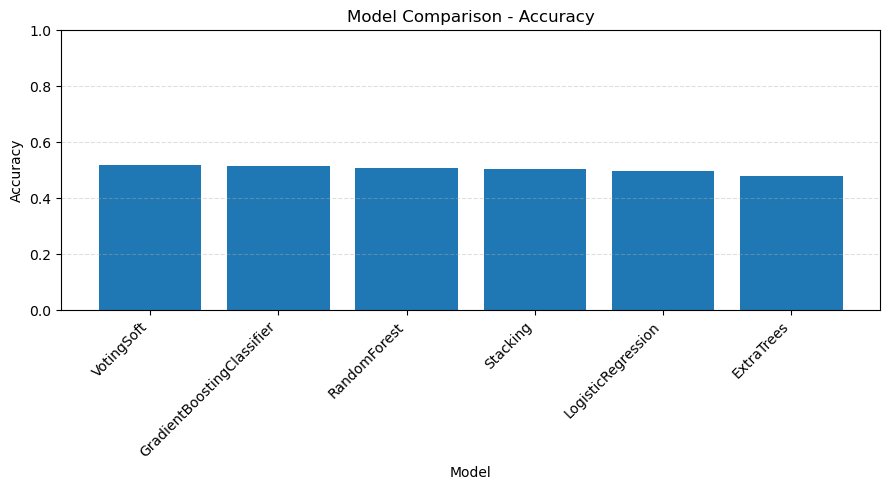

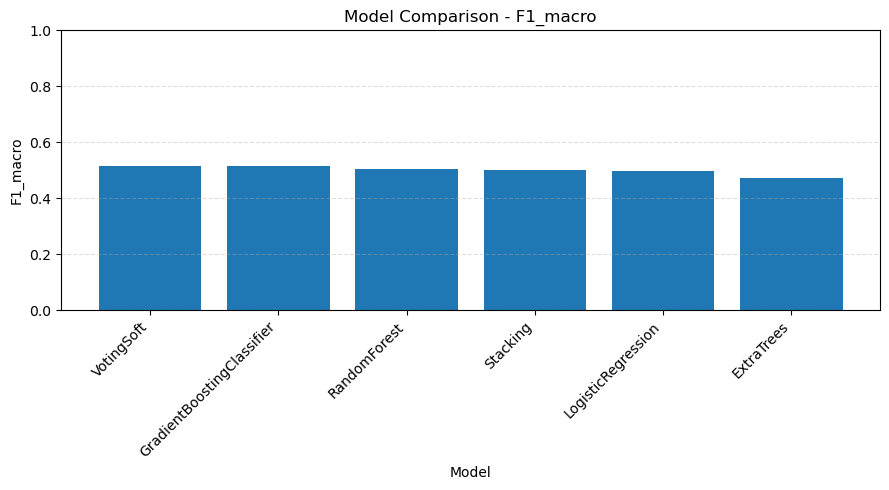

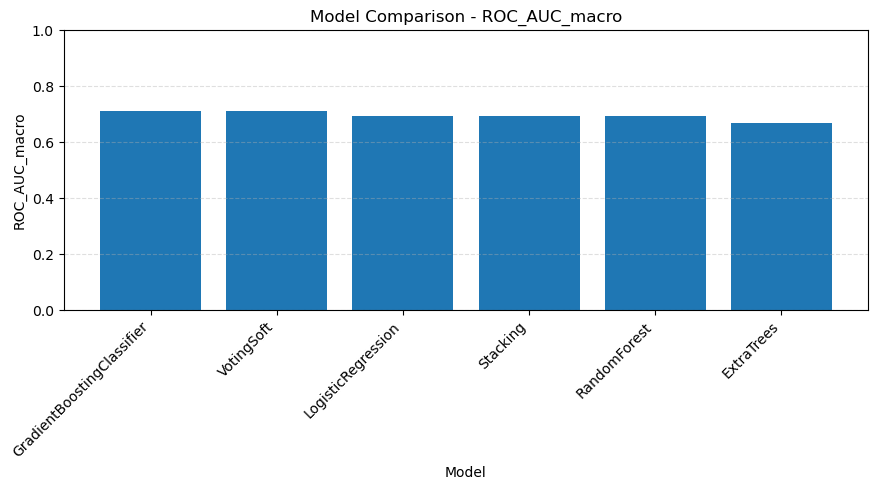

In [15]:
# ============================
# METRIC BAR PLOTS
# ============================

metric_cols = ["Accuracy", "F1_macro", "ROC_AUC_macro"]

for metric in metric_cols:
    plt.figure(figsize=(9, 5))
    plot_df = results_df.sort_values(metric, ascending=False)

    plt.bar(plot_df.index, plot_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

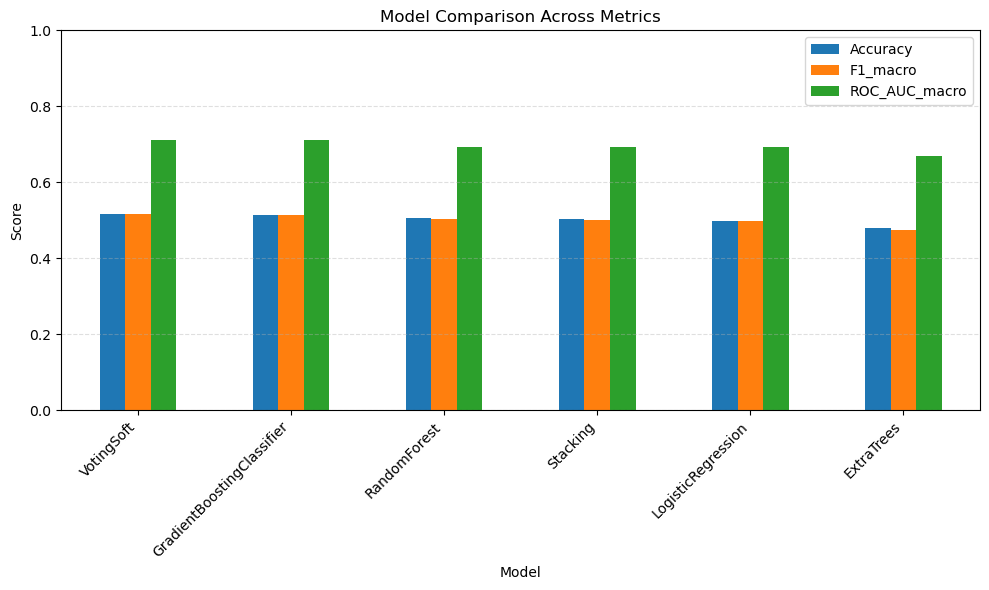

In [16]:
# ============================
# COMBINED METRIC PLOT
# ============================

plot_metrics = ["Accuracy", "F1_macro", "ROC_AUC_macro"]

plot_df = results_df[plot_metrics].copy()

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

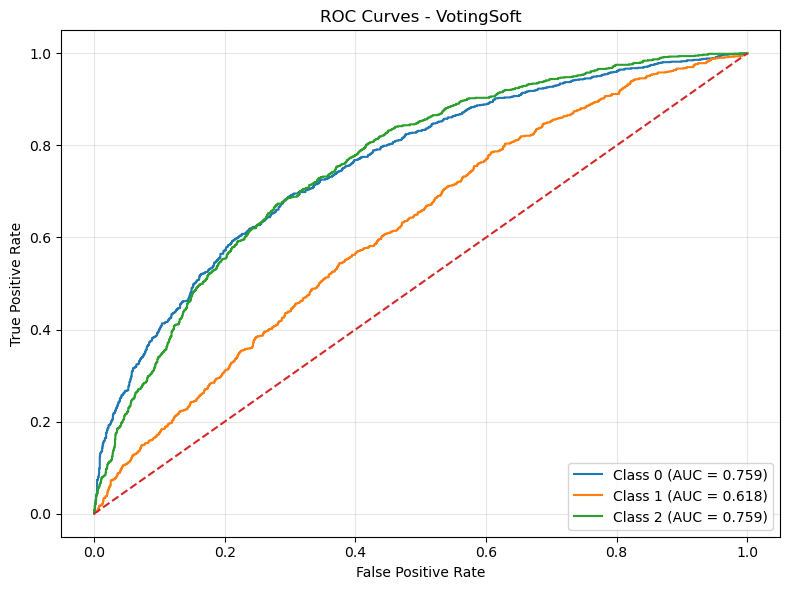

In [17]:
classes = np.sort(y_test.unique())

# ============================
# ROC CURVES - BEST MODEL
# ============================

best_model_name = results_df.index[0]
best_y_proba = pred_store[best_model_name]["y_proba"]

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    if len(np.unique(y_test_bin[:, i])) < 2:
        print(f"Skipping ROC for class {cls} because only one label present in y_test.")
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {best_model_name}")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ============================
# CROSS-VALIDATION — GBM (GroupKFold, 5 splits)
# ============================
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.pipeline import Pipeline as SklearnPipeline

gkf = GroupKFold(n_splits=5)

preprocess_cv, _, _ = build_preprocess_transformer(X_train)

pipe_cv = SklearnPipeline(steps=[
    ("preprocess", preprocess_cv),
    ("model", GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42
    ))
])

cv_splits = list(gkf.split(X, y, groups=groups))

cv_scores = cross_val_score(
    pipe_cv,
    X, y,
    cv=cv_splits,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("GBM CV F1_macro per fold:", np.round(cv_scores, 4))
print(f"Mean : {cv_scores.mean():.4f}")
print(f"Std  : {cv_scores.std():.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


GBM CV F1_macro per fold: [0.516  0.5316 0.528  0.5218 0.5382]
Mean : 0.5271
Std  : 0.0077


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   46.6s finished


In [19]:
# ============================
# SHAP — GradientBoostingClassifier
# ============================
import shap

best_model_name  = "GradientBoostingClassifier"
best_pipe        = trained_pipes[best_model_name]
gbm_model        = best_pipe.named_steps["model"]

# Transform data using fitted preprocessor
X_train_transformed = best_pipe.named_steps["preprocess"].transform(X_train)
X_test_transformed  = best_pipe.named_steps["preprocess"].transform(X_test)

# Get feature names
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df  = pd.DataFrame(X_test_transformed,  columns=feature_names)

# Sample for speed
background_size = min(200, len(X_train_transformed_df))
explain_size    = min(150, len(X_test_transformed_df))

X_background = X_train_transformed_df.sample(background_size, random_state=42)
X_explain    = X_test_transformed_df.sample(explain_size,    random_state=42)

# Compute SHAP — using Explainer (supports multiclass GBM)
explainer       = shap.Explainer(gbm_model.predict_proba, X_background)
shap_values_obj = explainer(X_explain)
shap_arr        = shap_values_obj.values
shap_values     = [shap_arr[:, :, i] for i in range(shap_arr.shape[2])]

print("SHAP computed ✓")
print("X_explain shape  :", X_explain.shape)
print("Number of classes:", len(shap_values))



PermutationExplainer explainer: 151it [00:42,  3.33it/s]                         

SHAP computed ✓
X_explain shape  : (150, 168)
Number of classes: 3



SHAP Global Bar Plot — Class 0


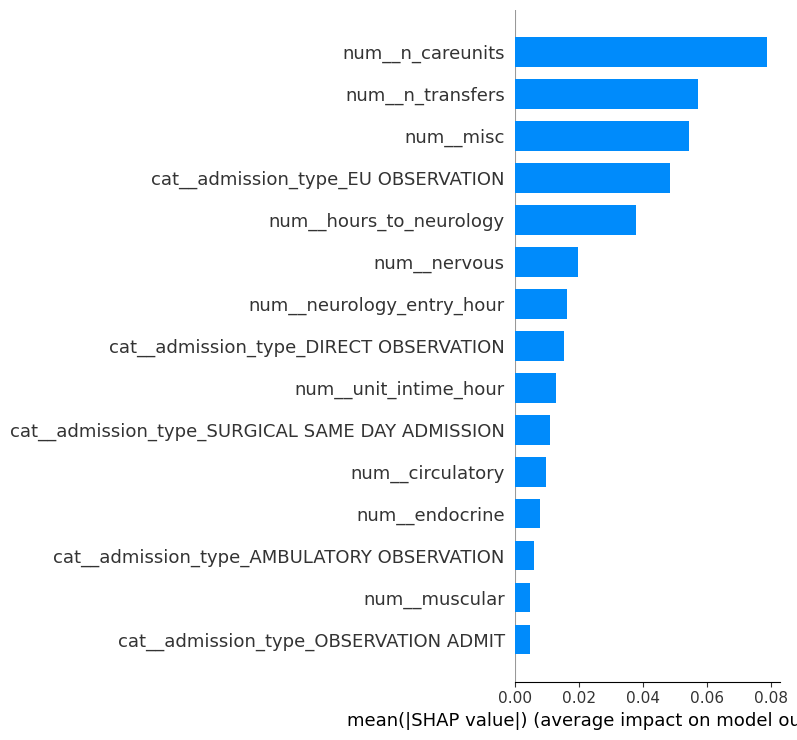


SHAP Global Bar Plot — Class 1


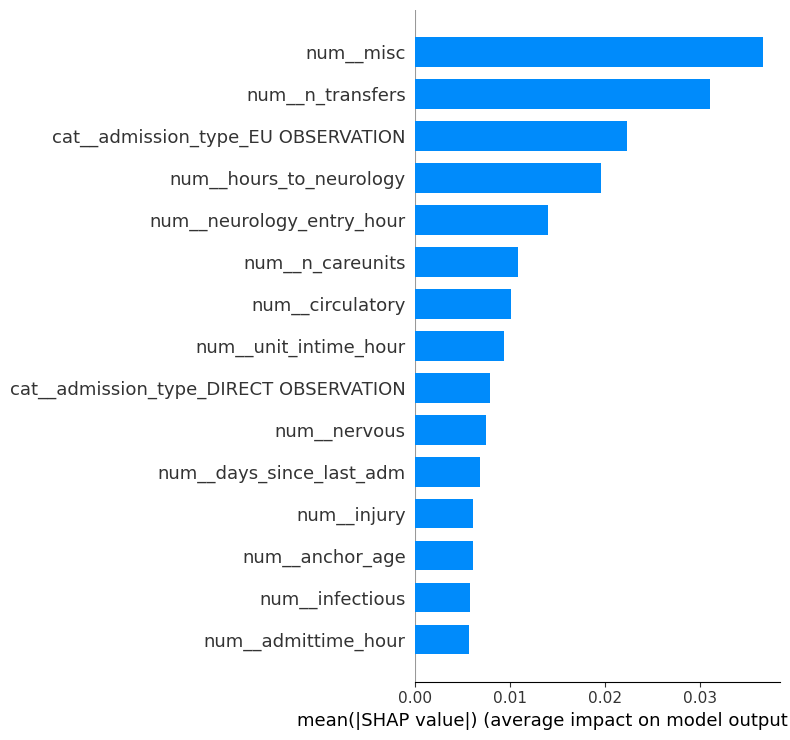


SHAP Global Bar Plot — Class 2


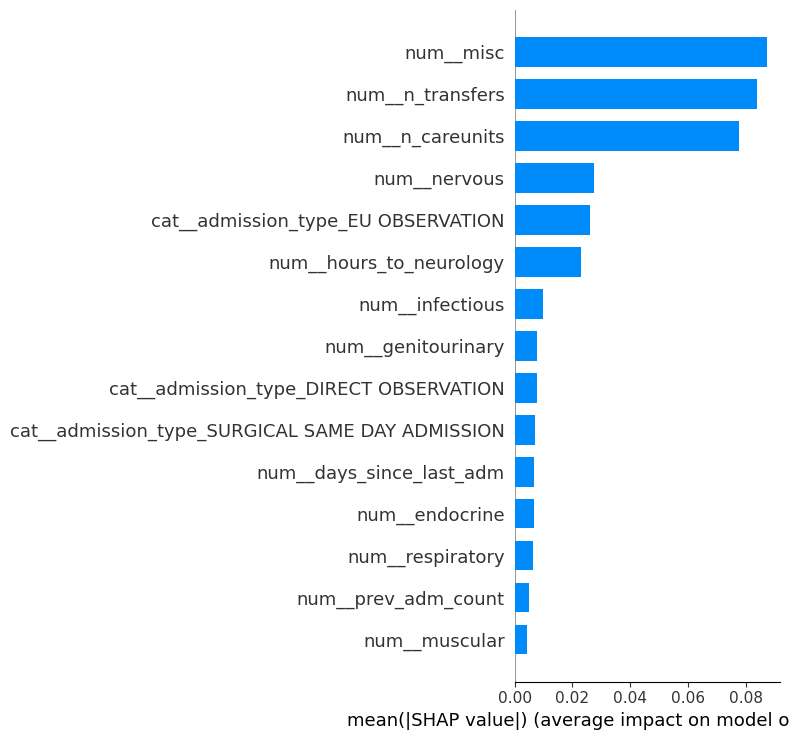

In [20]:
# Bar plots — one per class
for class_idx in range(len(shap_values)):
    print(f"\nSHAP Global Bar Plot — Class {class_idx}")
    shap.summary_plot(
        shap_values[class_idx],
        X_explain,
        plot_type="bar",
        max_display=15,
        show=True
    )




SHAP Beeswarm — Class 0


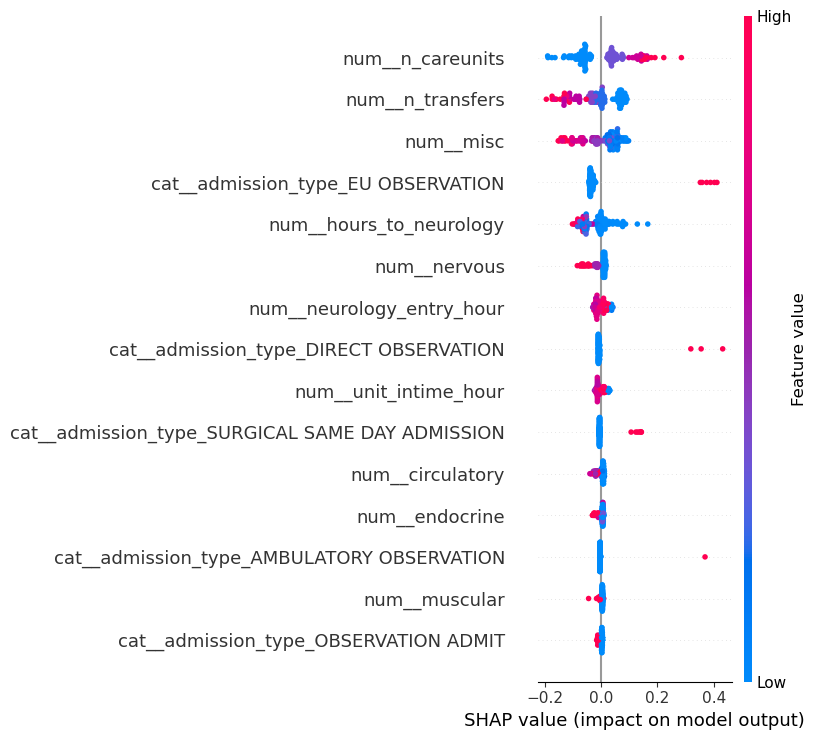


SHAP Beeswarm — Class 1


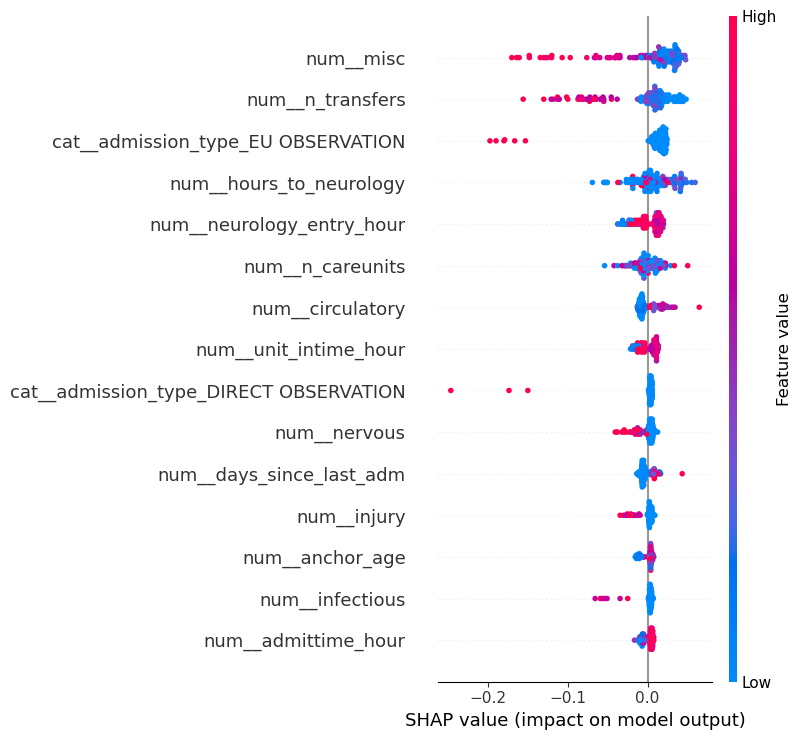


SHAP Beeswarm — Class 2


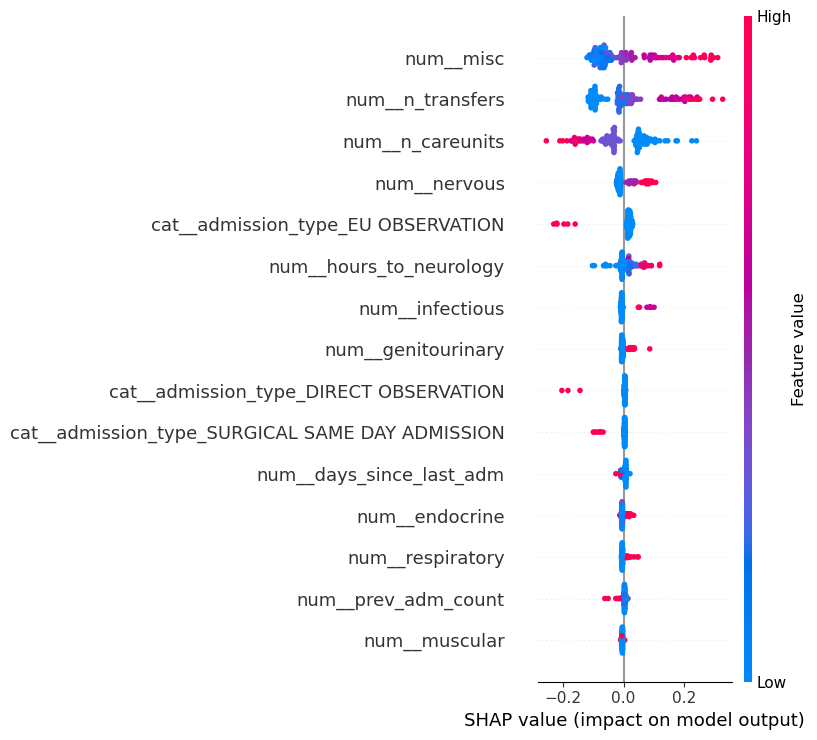

In [21]:
# Beeswarm plots — one per class
for class_idx in range(len(shap_values)):
    print(f"\nSHAP Beeswarm — Class {class_idx}")
    shap.summary_plot(
        shap_values[class_idx],
        X_explain,
        max_display=15,
        show=True
    )



In [22]:
# Global importance averaged across all 3 classes
mean_shap = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values], axis=0
)

shap_importance_df = pd.DataFrame({
    "feature":   feature_names,
    "mean_shap": mean_shap
}).sort_values("mean_shap", ascending=False).reset_index(drop=True)

print("\nTop 20 features by mean |SHAP| across all classes:")
print(shap_importance_df.head(20).to_string(index=False))




Top 20 features by mean |SHAP| across all classes:
                                        feature  mean_shap
                                      num__misc   0.059588
                               num__n_transfers   0.057359
                               num__n_careunits   0.055875
             cat__admission_type_EU OBSERVATION   0.032302
                        num__hours_to_neurology   0.026869
                                   num__nervous   0.018273
                      num__neurology_entry_hour   0.011399
         cat__admission_type_DIRECT OBSERVATION   0.010283
                          num__unit_intime_hour   0.008854
                               num__circulatory   0.007659
cat__admission_type_SURGICAL SAME DAY ADMISSION   0.007449
                                num__infectious   0.006455
                                 num__endocrine   0.005560
                             num__genitourinary   0.005313
                       num__days_since_last_adm   0.005109
    

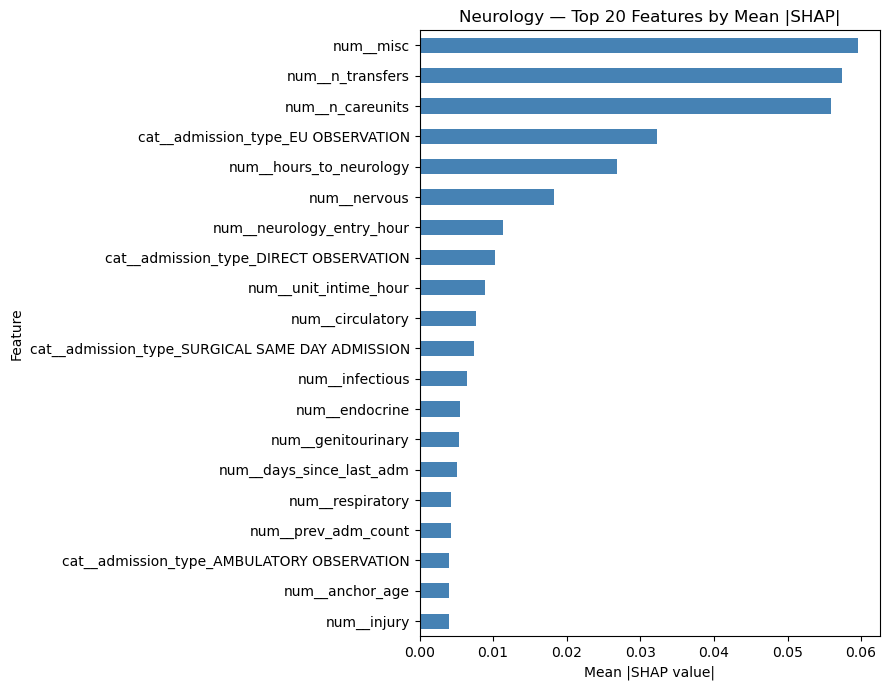

In [23]:
# Horizontal bar chart
shap_importance_df.head(20).sort_values("mean_shap").plot(
    kind="barh",
    x="feature",
    y="mean_shap",
    legend=False,
    color="steelblue",
    figsize=(9, 7)
)
plt.title("Neurology — Top 20 Features by Mean |SHAP|")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [24]:
def end_signature():
    print("="*40)
    print("END OF NOTEBOOK — AT")
    print("="*40)

end_signature()

END OF NOTEBOOK — AT


In [25]:
# Check what misc actually is
print(df_merge2["misc"].value_counts().head(10))
print(df_merge2["misc"].describe())

misc
1.0     1735
2.0     1538
0.0     1434
3.0     1210
4.0      740
5.0      573
10.0     426
14.0     414
7.0      411
6.0      406
Name: count, dtype: int64
count    14552.000000
mean         9.141149
std          9.076989
min          0.000000
25%          2.000000
50%          6.000000
75%         15.000000
max         39.000000
Name: misc, dtype: float64
